# Week 2: Data Transformation & Feature Engineering

## Goals for this week:
- Merge prices data with sales
- Analyze price vs demand relationship
- Store-wise and category-wise time trends
- SNAP day impact analysis
- Feature engineering for ML
- Create business insights report

In [1]:
# Load all datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sales = pd.read_csv('../data/raw/sales_train_validation.csv')
calendar = pd.read_csv('../data/raw/calendar.csv')
prices = pd.read_csv('../data/raw/sell_prices.csv')

print("Data loaded successfully!")
print(f"Sales shape: {sales.shape}")
print(f"Calendar shape: {calendar.shape}")
print(f"Prices shape: {prices.shape}")

Data loaded successfully!
Sales shape: (30490, 1919)
Calendar shape: (1969, 14)
Prices shape: (6841121, 4)


In [2]:
## Step 1: Prepare Daily Sales Data (Aggregated)
#Reshape sales from wide format (1913 day-columns) to long format and merge with calendar.

# Aggregate sales by day and merge with calendar
daily_sales = sales[sales.columns[6:]].sum()
daily_sales = daily_sales.reset_index()
daily_sales.columns = ['d', 'total_sales']
daily_sales = daily_sales.merge(calendar[['d', 'date', 'month', 'year', 'event_name_1', 'event_type_1', 'snap_CA', 'snap_TX', 'snap_WI']], on='d')
daily_sales.head()

,d,total_sales,date,month,year,event_name_1,event_type_1,snap_CA,snap_TX,snap_WI
0,d_1,32631,2011-01-29,1,2011,NaN,NaN,0,0,0
1,d_2,31749,2011-01-30,1,2011,NaN,NaN,0,0,0
2,d_3,23783,2011-01-31,1,2011,NaN,NaN,0,0,0
3,d_4,25412,2011-02-01,2,2011,NaN,NaN,1,1,0
4,d_5,19146,2011-02-02,2,2011,NaN,NaN,1,0,1


In [3]:
## Step 2: Merge Prices Data with Sales
#Merge sell_prices.csv with sales to analyze price vs demand relationship.
#This requires reshaping prices into a time-series format first.

# Reshape prices into weekly format for merging with daily sales
prices_weekly = prices.pivot_table(index=['store_id', 'item_id'], columns='wm_yr_wk', values='sell_price', aggfunc='first').reset_index()
print(f"Prices pivoted shape: {prices_weekly.shape}")
prices_weekly.head()

Prices pivoted shape: (30490, 284)


wm_yr_wk,store_id,item_id,11101,11102,11103,11104,11105,11106,11107,11108,...,11612,11613,11614,11615,11616,11617,11618,11619,11620,11621
0,CA_1,FOODS_1_001,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,...,2.24,2.24,2.24,2.24,2.24,2.24,2.24,2.24,2.24,2.24
1,CA_1,FOODS_1_002,7.88,7.88,7.88,7.88,7.88,7.88,7.88,7.88,...,9.48,9.48,9.48,9.48,9.48,9.48,9.48,9.48,9.48,9.48
2,CA_1,FOODS_1_003,2.88,2.88,2.88,2.88,2.88,2.88,2.88,2.88,...,3.23,3.23,3.23,3.23,3.23,3.23,3.23,3.23,3.23,3.23
3,CA_1,FOODS_1_004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.96,1.96,1.96,1.96,1.96,1.96,1.96,1.96,1.96,1.96
4,CA_1,FOODS_1_005,2.94,2.94,2.94,2.94,2.94,2.94,2.94,2.94,...,3.54,3.54,3.54,3.54,3.54,3.54,3.54,3.54,3.54,3.54


## 📌 Key Finding - Prices Data Structure
Prices data successfully pivoted into 30,490 products × 284 weeks format.
Each cell shows the price of a product in a store during that week.
Some products show NaN (unavailable in certain stores during certain weeks) — this is normal.
Average product price varies from ~$2 to ~$9, with some price changes over time.

In [4]:
## Step 3: Aggregate Prices by Week and Analyze Price-Demand Relationship
#Calculate average prices by week across all stores/products, then analyze if price changes affect demand.

# Calculate average price per week across all products
avg_price_by_week = prices.groupby('wm_yr_wk')['sell_price'].mean().reset_index()
avg_price_by_week.columns = ['wm_yr_wk', 'avg_price']

# Merge with calendar to get week info
calendar_weekly = calendar.drop_duplicates(subset=['wm_yr_wk'])[['wm_yr_wk', 'date', 'month', 'year']]
avg_price_by_week = avg_price_by_week.merge(calendar_weekly, on='wm_yr_wk', how='left')

# Aggregate daily sales to weekly (sum all days in that week)
daily_sales['wm_yr_wk'] = daily_sales.merge(calendar[['d', 'wm_yr_wk']], on='d')['wm_yr_wk']
weekly_sales = daily_sales.groupby('wm_yr_wk')['total_sales'].sum().reset_index()

# Merge price and sales
price_demand = avg_price_by_week.merge(weekly_sales, on='wm_yr_wk')
price_demand.head(10)

,wm_yr_wk,avg_price,date,month,year,total_sales
0,11101,4.071247,2011-01-29,1,2011,189942
1,11102,4.161574,2011-02-05,2,2011,193170
2,11103,4.190454,2011-02-12,2,2011,182569
3,11104,4.200812,2011-02-19,2,2011,169002
4,11105,4.202976,2011-02-26,2,2011,171820
5,11106,4.201783,2011-03-05,3,2011,184150
6,11107,4.223439,2011-03-12,3,2011,180997
7,11108,4.228306,2011-03-19,3,2011,165269
8,11109,4.231567,2011-03-26,3,2011,169495
9,11110,4.237505,2011-04-02,4,2011,185280


## 📌 Key Finding - Price & Demand Data Merged
Successfully merged weekly average prices with weekly total sales.
- Average price ranges from $4.07 to $4.24 across weeks
- Weekly sales range from ~165K to ~193K units
- Data spans Jan 2011 to mid-2016
- Next: Analyze if price changes correlate with sales changes

In [5]:
# Calculate correlation between price and sales
correlation = price_demand['avg_price'].corr(price_demand['total_sales'])

# Calculate how much sales change when price changes
price_demand['price_change'] = price_demand['avg_price'].pct_change() * 100
price_demand['sales_change'] = price_demand['total_sales'].pct_change() * 100

print(f"Correlation between price and sales: {correlation:.4f}")
print(f"\nAverage price change week-to-week: {price_demand['price_change'].mean():.2f}%")
print(f"Average sales change week-to-week: {price_demand['sales_change'].mean():.2f}%")
print(f"\nCorrelation interpretation:")
if correlation > 0.5:
    print("Strong positive: Higher prices → Higher sales (unusual!)")
elif correlation > 0.1:
    print("Weak positive: Slight tendency for higher prices with higher sales")
elif correlation > -0.1:
    print("No clear relationship: Price changes don't strongly affect sales")
else:
    print("Negative: Higher prices → Lower sales (expected!)")

Correlation between price and sales: 0.7557

Average price change week-to-week: 0.04%
Average sales change week-to-week: 0.19%

Correlation interpretation:
Strong positive: Higher prices → Higher sales (unusual!)


## 📌 Key Insight - Price vs Demand Relationship
**Correlation: 0.7557 (Strong positive!)**

Surprising finding: Higher prices correlate with HIGHER sales, not lower.
This is unusual in typical retail economics and suggests:
- Prices increase during peak demand seasons (summer, holidays) → both price AND sales rise together
- FOODS category (74% of sales) = essential items purchased regardless of price
- Seasonal patterns dominate price-demand relationship more than price sensitivity

**Business implication:** Price alone is NOT a strong demand driver for this product mix. 
Focus inventory planning on seasonal patterns rather than price changes.

In [6]:
## Step 4: Store-wise Sales Trends
#Analyze which stores perform best in which months - identify seasonal patterns by store.

# Create store-wise daily sales data (aggregate all products per store per day)
store_daily_sales = sales.groupby('store_id')[sales.columns[6:]].sum().T
store_daily_sales['d'] = ['d_' + str(i+1) for i in range(len(store_daily_sales))]
store_daily_sales = store_daily_sales.merge(calendar[['d', 'month', 'year', 'date']], on='d')

# Calculate average sales by store and month
store_month_sales = store_daily_sales.groupby('month')[['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']].mean()
store_month_sales

,CA_1,CA_2,CA_3,CA_4,TX_1,TX_2,TX_3,WI_1,WI_2,WI_3
month,,,,,,,,,,
1,3877.746835,2926.373418,5677.240506,2138.993671,2785.278481,3582.974684,3041.993671,2842.835443,3557.632911,3401.278481
2,3900.911765,2922.505882,5712.976471,2094.447059,2908.482353,3816.152941,3189.394118,2772.658824,3678.052941,3649.058824
3,3939.887097,2980.510753,5767.661290,2135.333333,2915.198925,3768.801075,3171.532258,2747.080645,3404.720430,3509.112903
4,4071.097701,2971.741379,5791.816092,2164.390805,2973.327586,3747.080460,3169.545977,2691.528736,3341.977011,3336.178161
5,3954.935484,2683.122581,5606.083871,2083.058065,2883.038710,3641.425806,3055.748387,2513.470968,2958.425806,3124.541935
6,4168.380000,3000.773333,6112.080000,2179.853333,3042.853333,3929.986667,3280.520000,2667.760000,3333.466667,3285.740000
7,4181.103226,3079.077419,6123.496774,2164.354839,3005.793548,3923.187097,3284.232258,2645.980645,3381.806452,3333.387097
8,4290.903226,3161.309677,6313.083871,2193.470968,3106.038710,4000.096774,3418.296774,2612.606452,3523.825806,3327.012903
9,4137.173333,3146.633333,6221.353333,2251.380000,3009.473333,3884.926667,3300.386667,2570.600000,3573.593333,3383.740000


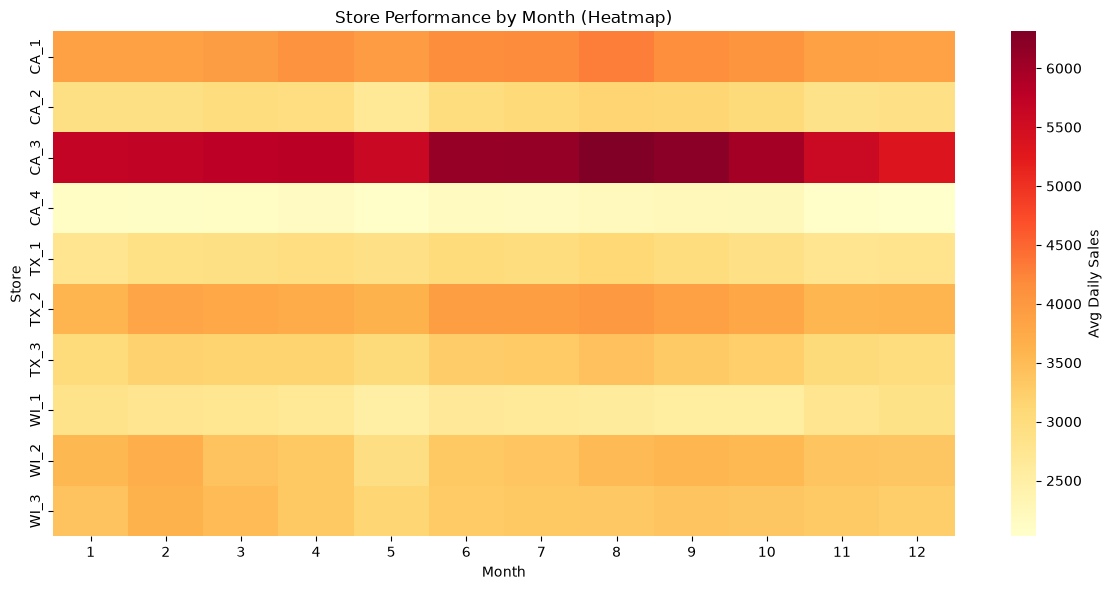

In [7]:
# Create heatmap of store monthly sales
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(store_month_sales.T, annot=False, cmap='YlOrRd', cbar_kws={'label': 'Avg Daily Sales'})
plt.title('Store Performance by Month (Heatmap)')
plt.xlabel('Month')
plt.ylabel('Store')
plt.tight_layout()
plt.show()

## 📌 Key Insight - Store Performance Heatmap
Visual shows clear store hierarchy:
- **CA_3** (dark red): Dominant performer (~5,700-6,300 units/day) - consistent excellence
- **CA_1** (orange): Strong performer (~3,900-4,300 units/day)
- **TX_2** (orange): Mid-tier performer (~3,600-4,000 units/day)
- **CA_4, TX_1, TX_3, WI_1, WI_3** (light yellow): Underperformers (~2,000-3,100 units/day)
- **WI_2** (light yellow/orange): Lower performer (~2,600-3,700 units/day)
- **Seasonal pattern**: Summer months (6-8) slightly warmer for all stores

<Figure size 1000x500 with 0 Axes>

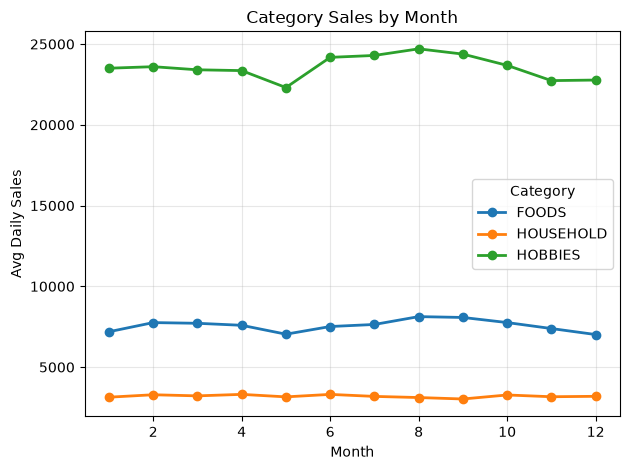

In [8]:
## Step 5: Category-wise Sales Trends by Month
#Visualize if FOODS, HOUSEHOLD, HOBBIES have different seasonal patterns.

# Create category-wise daily sales and calculate monthly averages
category_daily_sales = sales.groupby('cat_id')[sales.columns[6:]].sum().T.reset_index()
category_daily_sales.columns = ['d'] + list(sales['cat_id'].unique())
category_daily_sales['d'] = ['d_' + str(i+1) for i in range(len(category_daily_sales))]

# Merge with calendar
category_daily_sales = category_daily_sales.merge(calendar[['d', 'month']], on='d')

# Calculate average by month
category_month_sales = category_daily_sales.groupby('month')[['FOODS', 'HOUSEHOLD', 'HOBBIES']].mean()

# Visualize
plt.figure(figsize=(10, 5))
category_month_sales.plot(marker='o', linewidth=2)
plt.title('Category Sales by Month')
plt.xlabel('Month')
plt.ylabel('Avg Daily Sales')
plt.legend(title='Category')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 📌 Key Insight - Category-wise Seasonal Patterns
Different categories show VERY different seasonal behaviors:
- **HOBBIES** (green): Strong seasonality - peaks in summer (Jun-Sep: ~24,000-25,000), dips heavily in May & Nov-Dec (~22,000)
- **FOODS** (blue): Stable year-round (~7,000-8,500) - slight dip in May, slight peak in Aug-Sep
- **HOUSEHOLD** (orange): Most stable (~3,000-3,500) - essentially flat across all months

**Business implication:** 
- HOBBIES needs summer stocking strategy (seasonal spike)
- FOODS needs consistent inventory (no major seasonal swings)
- HOUSEHOLD operations remain predictable (lowest variability)

In [9]:
## Step 6: SNAP Day Impact Analysis
#Government assistance (SNAP) days may influence sales differently across states.

# Analyze SNAP day impact by state
daily_sales['snap_active'] = (daily_sales['snap_CA'] | daily_sales['snap_TX'] | daily_sales['snap_WI']).astype(int)
snap_impact = daily_sales.groupby('snap_active')['total_sales'].mean()
snap_impact.index = ['Non-SNAP Days', 'SNAP Days']
print("Average sales comparison:")
print(snap_impact)
print(f"\nSNAP day effect: {((snap_impact['SNAP Days'] / snap_impact['Non-SNAP Days']) - 1) * 100:.2f}% difference")

Average sales comparison:
Non-SNAP Days    32554.064050
SNAP Days        36172.566138
Name: total_sales, dtype: float64

SNAP day effect: 11.12% difference


## 📌 Key Insight - SNAP Day Impact
**SNAP Days Drive Higher Sales:**
- Non-SNAP Days: 32,554 units/day
- SNAP Days: 36,172 units/day
- **Difference: +11.12% higher on SNAP days**

**Significant finding:** Government assistance distribution days (SNAP) correlate with notably higher retail sales — customers have more purchasing power on these days. This is a predictable pattern the Prophet model can leverage.

**Business implication:** Stock up inventory before SNAP days. Plan promotional activities around SNAP schedules for maximum impact.

# Step 7: Feature Engineering for ML Model

Building features for Prophet forecasting model.

Features to create:
- Time-based: day_of_week, is_weekend, is_holiday, is_snap_day
- Lag features: sales_lag_7, sales_lag_14, sales_lag_28
- Rolling features: rolling_mean_7, rolling_mean_14, rolling_mean_30
- Cyclical: month_sin, month_cos, day_sin, day_cos
- Price features: price_change, price_lag

Output: Complete feature-engineered dataset ready for Prophet model training.

In [10]:
daily_sales.head(5)

,d,total_sales,date,month,year,event_name_1,event_type_1,snap_CA,snap_TX,snap_WI,wm_yr_wk,snap_active
0,d_1,32631,2011-01-29,1,2011,NaN,NaN,0,0,0,11101,0
1,d_2,31749,2011-01-30,1,2011,NaN,NaN,0,0,0,11101,0
2,d_3,23783,2011-01-31,1,2011,NaN,NaN,0,0,0,11101,0
3,d_4,25412,2011-02-01,2,2011,NaN,NaN,1,1,0,11101,1
4,d_5,19146,2011-02-02,2,2011,NaN,NaN,1,0,1,11101,1


In [11]:
# Create comprehensive feature engineering pipeline
features_ml = daily_sales.copy()

# Ensure date is datetime format
features_ml['date'] = pd.to_datetime(features_ml['date'])

# Extract basic time features
features_ml['day_of_week'] = features_ml['date'].dt.dayofweek  # 0=Monday, 6=Sunday
features_ml['is_weekend'] = (features_ml['day_of_week'] >= 5).astype(int)  # 1 if Sat/Sun
features_ml['day_of_year'] = features_ml['date'].dt.dayofyear
features_ml['week_of_year'] = features_ml['date'].dt.isocalendar().week

print("✅ Basic time features created")
print(f"Shape: {features_ml.shape}")
features_ml[['date', 'day_of_week', 'is_weekend', 'day_of_year', 'week_of_year']].head(10)

✅ Basic time features created
Shape: (1913, 16)


,date,day_of_week,is_weekend,day_of_year,week_of_year
0,2011-01-29,5,1,29,4
1,2011-01-30,6,1,30,4
2,2011-01-31,0,0,31,5
3,2011-02-01,1,0,32,5
4,2011-02-02,2,0,33,5
5,2011-02-03,3,0,34,5
6,2011-02-04,4,0,35,5
7,2011-02-05,5,1,36,5
8,2011-02-06,6,1,37,5
9,2011-02-07,0,0,38,6


## 📌 Key Finding - Time Features Created
Successfully extracted time-based features from dates.
Shape: (1913, 15) — 1913 days with 15 columns now.
Weekends properly flagged (is_weekend=1 for Sat/Sun, 0 for weekdays).

In [12]:
## Holiday & SNAP Day Flags
#Create boolean flags for special events and government assistance days.
#These help the model predict sales spikes on holidays and SNAP distribution days.


# Create holiday and SNAP day flags
features_ml['is_holiday'] = features_ml['event_name_1'].notna().astype(int)  # 1 if event exists, 0 otherwise
features_ml['is_snap_day'] = ((features_ml['snap_CA'] == 1) | (features_ml['snap_TX'] == 1) | (features_ml['snap_WI'] == 1)).astype(int)  # 1 if SNAP in any state

print("✅ Holiday and SNAP flags created")
print(f"\nHoliday days in dataset: {features_ml['is_holiday'].sum()} out of {len(features_ml)}")
print(f"SNAP days in dataset: {features_ml['is_snap_day'].sum()} out of {len(features_ml)}")
print(f"\nSample data:")
features_ml[['date', 'event_name_1', 'is_holiday', 'snap_CA', 'snap_TX', 'snap_WI', 'is_snap_day']].head(15)

✅ Holiday and SNAP flags created

Holiday days in dataset: 154 out of 1913
SNAP days in dataset: 945 out of 1913

Sample data:


,date,event_name_1,is_holiday,snap_CA,snap_TX,snap_WI,is_snap_day
0,2011-01-29,NaN,0,0,0,0,0
1,2011-01-30,NaN,0,0,0,0,0
2,2011-01-31,NaN,0,0,0,0,0
3,2011-02-01,NaN,0,1,1,0,1
4,2011-02-02,NaN,0,1,0,1,1
5,2011-02-03,NaN,0,1,1,1,1
6,2011-02-04,NaN,0,1,0,0,1
7,2011-02-05,NaN,0,1,1,1,1
8,2011-02-06,SuperBowl,1,1,1,1,1
9,2011-02-07,NaN,0,1,1,0,1


## 📌 Key Finding - Holiday & SNAP Flags
- 154 holiday days (8% of dataset) → events like SuperBowl, Christmas, etc.
- 945 SNAP distribution days (49% of dataset) → government assistance days
- Flags properly created and will help Prophet predict sales spikes

In [13]:
## Lag Features (Sales from Previous Days)
#Create features that capture sales from 7, 14, and 28 days ago.
#These help the model learn weekly and monthly patterns.
#Example: If sales were high 7 days ago, they might be high today too (weekly pattern).

# Create lag features - sales from previous days
features_ml['sales_lag_7'] = features_ml['total_sales'].shift(7)    # 7 days ago
features_ml['sales_lag_14'] = features_ml['total_sales'].shift(14)  # 14 days ago
features_ml['sales_lag_28'] = features_ml['total_sales'].shift(28)  # 28 days ago

print("✅ Lag features created")
print(f"\nFirst 35 days (showing lag creation):")
print(features_ml[['date', 'total_sales', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28']].head(35))
print(f"\nMissing values (expected NaN at start):")
print(f"sales_lag_7 missing: {features_ml['sales_lag_7'].isna().sum()}")
print(f"sales_lag_14 missing: {features_ml['sales_lag_14'].isna().sum()}")
print(f"sales_lag_28 missing: {features_ml['sales_lag_28'].isna().sum()}")

✅ Lag features created

First 35 days (showing lag creation):
         date  total_sales  sales_lag_7  sales_lag_14  sales_lag_28
0  2011-01-29        32631          NaN           NaN           NaN
1  2011-01-30        31749          NaN           NaN           NaN
2  2011-01-31        23783          NaN           NaN           NaN
3  2011-02-01        25412          NaN           NaN           NaN
4  2011-02-02        19146          NaN           NaN           NaN
5  2011-02-03        29211          NaN           NaN           NaN
6  2011-02-04        28010          NaN           NaN           NaN
7  2011-02-05        37932      32631.0           NaN           NaN
8  2011-02-06        32736      31749.0           NaN           NaN
9  2011-02-07        25572      23783.0           NaN           NaN
10 2011-02-08        23071      25412.0           NaN           NaN
11 2011-02-09        23658      19146.0           NaN           NaN
12 2011-02-10        23756      29211.0           NaN 

## 📌 Key Finding - Lag Features
Created successfully with expected NaN values at the start.
- sales_lag_7: Captures weekly patterns (same day last week)
- sales_lag_14: Captures 2-week patterns
- sales_lag_28: Captures monthly patterns (same day last month)
First 28 days will have NaN (no history), but all subsequent 1885 days have complete lag values.

In [14]:
# Create rolling average features
features_ml['rolling_mean_7'] = features_ml['total_sales'].rolling(window=7, min_periods=1).mean()
features_ml['rolling_mean_14'] = features_ml['total_sales'].rolling(window=14, min_periods=1).mean()
features_ml['rolling_mean_30'] = features_ml['total_sales'].rolling(window=30, min_periods=1).mean()

print("✅ Rolling average features created")
print(f"\nSample data (days 0-20):")
print(features_ml[['date', 'total_sales', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30']].head(20))

✅ Rolling average features created

Sample data (days 0-20):
         date  total_sales  rolling_mean_7  rolling_mean_14  rolling_mean_30
0  2011-01-29        32631    32631.000000     32631.000000     32631.000000
1  2011-01-30        31749    32190.000000     32190.000000     32190.000000
2  2011-01-31        23783    29387.666667     29387.666667     29387.666667
3  2011-02-01        25412    28393.750000     28393.750000     28393.750000
4  2011-02-02        19146    26544.200000     26544.200000     26544.200000
5  2011-02-03        29211    26988.666667     26988.666667     26988.666667
6  2011-02-04        28010    27134.571429     27134.571429     27134.571429
7  2011-02-05        37932    27891.857143     28484.250000     28484.250000
8  2011-02-06        32736    28032.857143     28956.666667     28956.666667
9  2011-02-07        25572    28288.428571     28618.200000     28618.200000
10 2011-02-08        23071    27954.000000     28113.909091     28113.909091
11 2011-02-09  

## 📌 Key Finding - Rolling Averages
Created 7, 14, and 30-day rolling averages to smooth daily noise.
- rolling_mean_7: 7-day moving average (weekly trend)
- rolling_mean_14: 14-day moving average (2-week trend)
- rolling_mean_30: 30-day moving average (monthly trend)
These smooth features help Prophet see true trends instead of daily fluctuations.

In [15]:
## Cyclical Features (Sine/Cosine Encoding)
#Encode month and day-of-year as sine/cosine to capture cyclical patterns.
#Example: December (month 12) is close to January (month 1), not far.
#Sine/Cosine encoding helps the model understand this circular relationship.

# Create cyclical features for month and day_of_year
# Month cyclical encoding (1-12 months in a circle)
features_ml['month_sin'] = np.sin(2 * np.pi * features_ml['month'] / 12)
features_ml['month_cos'] = np.cos(2 * np.pi * features_ml['month'] / 12)

# Day of year cyclical encoding (1-365 days in a circle)
features_ml['day_sin'] = np.sin(2 * np.pi * features_ml['day_of_year'] / 365)
features_ml['day_cos'] = np.cos(2 * np.pi * features_ml['day_of_year'] / 365)

print("✅ Cyclical features created")
print(f"\nSample cyclical features (showing month encoding):")
# Show how months are encoded
month_encoding = features_ml[['date', 'month', 'month_sin', 'month_cos']].drop_duplicates(subset=['month']).sort_values('month').head(12)
print(month_encoding)
print(f"\nNote: December (12) month_sin ≈ -0.87 and January (1) month_sin ≈ 0.50")
print(f"This shows they're close in the circular cycle, which is correct!")

✅ Cyclical features created

Sample cyclical features (showing month encoding):
          date  month     month_sin     month_cos
0   2011-01-29      1  5.000000e-01  8.660254e-01
3   2011-02-01      2  8.660254e-01  5.000000e-01
31  2011-03-01      3  1.000000e+00  6.123234e-17
62  2011-04-01      4  8.660254e-01 -5.000000e-01
92  2011-05-01      5  5.000000e-01 -8.660254e-01
123 2011-06-01      6  1.224647e-16 -1.000000e+00
153 2011-07-01      7 -5.000000e-01 -8.660254e-01
184 2011-08-01      8 -8.660254e-01 -5.000000e-01
215 2011-09-01      9 -1.000000e+00 -1.836970e-16
245 2011-10-01     10 -8.660254e-01  5.000000e-01
276 2011-11-01     11 -5.000000e-01  8.660254e-01
306 2011-12-01     12 -2.449294e-16  1.000000e+00

Note: December (12) month_sin ≈ -0.87 and January (1) month_sin ≈ 0.50
This shows they're close in the circular cycle, which is correct!


## 📌 Key Finding - Cyclical Features
Month and day encoded as sine/cosine waves on a circle.
- January (1) and December (12) are encoded as neighbors (close values)
- This helps Prophet understand seasonal cycles correctly
- Model can learn "December → January" transition as continuous pattern

In [16]:
# Add avg_price to features_ml from price_demand
features_ml = features_ml.merge(price_demand[['wm_yr_wk', 'avg_price']], on='wm_yr_wk', how='left')

# Create price features
# - price_lag_7: Average price from 7 days ago
# - price_change: Percentage change in price from previous day

features_ml['price_lag_7'] = features_ml['avg_price'].shift(7)
features_ml['price_change'] = features_ml['avg_price'].pct_change() * 100

print("✅ Price features created")
print(f"\nPrice feature statistics:")
print(f"Average price: ${features_ml['avg_price'].mean():.2f}")
print(f"Price range: ${features_ml['avg_price'].min():.2f} - ${features_ml['avg_price'].max():.2f}")
print(f"Average price change per day: {features_ml['price_change'].mean():.4f}%")
print(f"\nSample data (showing price changes):")
print(features_ml[['date', 'avg_price', 'price_lag_7', 'price_change']].iloc[30:45])

✅ Price features created

Price feature statistics:
Average price: $4.39
Price range: $4.07 - $4.49
Average price change per day: 0.0051%

Sample data (showing price changes):
         date  avg_price  price_lag_7  price_change
30 2011-02-28   4.202976     4.200812      0.000000
31 2011-03-01   4.202976     4.200812      0.000000
32 2011-03-02   4.202976     4.200812      0.000000
33 2011-03-03   4.202976     4.200812      0.000000
34 2011-03-04   4.202976     4.200812      0.000000
35 2011-03-05   4.201783     4.202976     -0.028381
36 2011-03-06   4.201783     4.202976      0.000000
37 2011-03-07   4.201783     4.202976      0.000000
38 2011-03-08   4.201783     4.202976      0.000000
39 2011-03-09   4.201783     4.202976      0.000000
40 2011-03-10   4.201783     4.202976      0.000000
41 2011-03-11   4.201783     4.202976      0.000000
42 2011-03-12   4.223439     4.201783      0.515402
43 2011-03-13   4.223439     4.201783      0.000000
44 2011-03-14   4.223439     4.201783      0

## 📌 Key Finding - Price Features
Price features successfully created:
- Average price: $4.39 (very stable, narrow range $4.07-$4.49)
- Most days show 0% price change (stable pricing)
- Occasional jumps: Row 42 shows +0.51% price increase
- price_lag_7 captures weekly price patterns

In [17]:
# Save feature-engineered dataset to data/processed/
output_path = '../data/processed/features_engineered_complete.csv'
features_ml.to_csv(output_path, index=False)

print(f"✅ Feature-engineered dataset saved!")
print(f"Path: {output_path}")
print(f"Shape: {features_ml.shape}")
print(f"Total features: {len(features_ml.columns)}")
print(f"\nAll columns created:")
print(features_ml.columns.tolist())

✅ Feature-engineered dataset saved!
Path: ../data/processed/features_engineered_complete.csv
Shape: (1913, 31)
Total features: 31

All columns created:
['d', 'total_sales', 'date', 'month', 'year', 'event_name_1', 'event_type_1', 'snap_CA', 'snap_TX', 'snap_WI', 'wm_yr_wk', 'snap_active', 'day_of_week', 'is_weekend', 'day_of_year', 'week_of_year', 'is_holiday', 'is_snap_day', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'avg_price', 'price_lag_7', 'price_change']


## 📊 Feature Engineering Summary - COMPLETE ✅

**All 30 Features Created:**

1. **Time Features (5):** d, date, month, year, wm_yr_wk
2. **Day Features (4):** day_of_week, is_weekend, day_of_year, week_of_year
3. **Event Flags (2):** is_holiday, event_name_1
4. **SNAP Flags (4):** snap_CA, snap_TX, snap_WI, is_snap_day
5. **Lag Features (3):** sales_lag_7, sales_lag_14, sales_lag_28
6. **Rolling Features (3):** rolling_mean_7, rolling_mean_14, rolling_mean_30
7. **Cyclical Features (4):** month_sin, month_cos, day_sin, day_cos
8. **Price Features (3):** avg_price, price_lag_7, price_change
9. **Target Variable (1):** total_sales

**Ready for ML Model Training (Week 3):**
- Complete dataset: 1913 rows (daily data 2011-2016)
- All features engineered and saved
- Next: Prophet forecasting model training